# 🗄️ SQL Analysis

## Objective

The objective of this notebook is to answer key business questions using SQL queries.

SQL remains one of the most important tools for Data Analysts because organizations store operational data in relational databases.

This notebook demonstrates how business insights can be extracted using SQL.

In [9]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
df = pd.read_csv("../data/processed/aeroengine_feature_engineered.csv")
df.head()

,Engine_ID,Cycle,Operational_Setting_1,Operational_Setting_2,Sensor_2,Sensor_3,Sensor_4,Sensor_6,Sensor_7,Sensor_8,...,Sensor_14,Sensor_15,Sensor_17,Sensor_20,Sensor_21,Engine_Life,RUL,Engine_Status,Average_Sensor_Value,Sensor_Variability
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,...,8138.62,8.4195,392,39.06,23.4190,192,191,Healthy,1813.400567,2875.867171
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,...,8131.49,8.4318,392,39.00,23.4236,192,190,Healthy,1813.117693,2874.319802
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,...,8133.23,8.4178,390,38.95,23.3442,192,189,Healthy,1813.539467,2876.258108
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,...,8133.83,8.3682,392,38.88,23.3739,192,188,Healthy,1813.012140,2875.704060
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,...,8133.80,8.4294,393,38.90,23.4044,192,187,Healthy,1813.686920,2876.660958


In [10]:
conn = sqlite3.connect(":memory:")

df.to_sql(
    "engine_data",
    conn,
    index=False,
    if_exists="replace"
)

20631

In [11]:
query = """
SELECT COUNT(DISTINCT Engine_ID) AS Total_Engines
FROM engine_data;
"""

pd.read_sql(query, conn)

,Total_Engines
0,100


### Business Insight

The dataset contains multiple unique aircraft engines monitored across their operational life cycles.

Knowing the fleet size helps estimate maintenance workload.

In [12]:
query = """
SELECT
Engine_ID,
MAX(Engine_Life) AS Total_Cycles
FROM engine_data
GROUP BY Engine_ID
ORDER BY Total_Cycles DESC
LIMIT 10;
"""

pd.read_sql(query, conn)

,Engine_ID,Total_Cycles
0,69,362
1,92,341
2,96,336
3,67,313
4,83,293
5,2,287
6,95,283
7,64,283
8,86,278
9,17,276


In [13]:
query = """
SELECT
AVG(RUL) AS Average_RUL
FROM engine_data;
"""

pd.read_sql(query, conn)

,Average_RUL
0,107.807862


Average Remaining Useful Life provides an estimate of how much operational life remains across the fleet.

In [14]:
query = """
SELECT
Engine_Status,
COUNT(*) AS Total
FROM engine_data
GROUP BY Engine_Status
ORDER BY Total DESC;
"""

status_df = pd.read_sql(query, conn)

status_df

,Engine_Status,Total
0,Healthy,10531
1,Critical,5100
2,Warning,5000


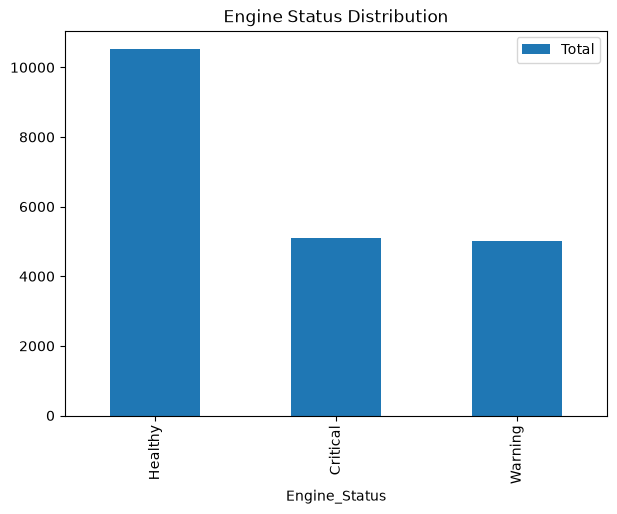

In [15]:
status_df.plot(
    kind="bar",
    x="Engine_Status",
    y="Total",
    figsize=(7,5)
)
plt.title("Engine Status Distribution")
plt.show()

In [16]:
query = """
SELECT
Engine_Status,
ROUND(AVG(Sensor_Variability),2) AS Avg_Sensor_Variability
FROM engine_data
GROUP BY Engine_Status;
"""

pd.read_sql(query, conn)

,Engine_Status,Avg_Sensor_Variability
0,Critical,2884.59
1,Healthy,2877.94
2,Warning,2879.64


In [17]:
query = """
SELECT
Engine_ID,
MAX(RUL) AS Remaining_Cycles
FROM engine_data
WHERE Engine_Status='Critical'
GROUP BY Engine_ID
ORDER BY Remaining_Cycles;
"""

critical_df = pd.read_sql(query, conn)

critical_df.head(10)

,Engine_ID,Remaining_Cycles
0,1,50
1,2,50
2,3,50
3,4,50
4,5,50
5,6,50
6,7,50
7,8,50
8,9,50
9,10,50


Critical engines should receive immediate inspection and maintenance scheduling to minimize operational risk.

In [18]:
query = """
SELECT
ROUND(AVG(Engine_Life),2) AS Average_Engine_Life
FROM engine_data;
"""

pd.read_sql(query, conn)

,Average_Engine_Life
0,216.62


# SQL Summary

| SQL Query           | Business Purpose      |
| ------------------- | --------------------- |
| Count Engines       | Fleet Size            |
| Top Engine Lifetime | Reliability           |
| Average RUL         | Maintenance Planning  |
| Engine Status       | Maintenance Priority  |
| Sensor Variability  | Operational Stability |
| Critical Engines    | Immediate Action      |
| Average Lifetime    | Fleet Performance     |
